Prototipo de facil acesso da visão computacional, lentidão se da devido a limtações do colab

# preparaçoes importações/dependencias

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
!pip install ultralytics
!pip install roboflow

In [ ]:
!pip install numpy

# prototipo

### treino manual

In [ ]:

from google.colab import files
import zipfile

# 1. Abre janela de upload
uploaded = files.upload()

# 2. Extrai o zip
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extraído")

# 3. Confirma estrutura
import os
for f in os.listdir("/content/dataset"):
    print(f)

Saving testes.v2i.yolov8.zip to testes.v2i.yolov8.zip
Dataset extraído
README.dataset.txt
valid
test
README.roboflow.txt
data.yaml
train


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640
)

model = YOLO("runs/detect/train/weights/best.pt")
print("Modelo treinado")

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

### treino "semi" manual


In [ ]:
from google.colab import drive
from ultralytics import YOLO
drive.mount('/content/drive')
import os
# Verificar se o modelo já existe no Drive
modelo_existe = os.path.exists("/content/drive/MyDrive/modelos_IA/meu_modelo.pt")#meu_modelo.pt
print("Modelo salvo no Drive:", modelo_existe)
if not modelo_existe:
    import zipfile

    # Extrair dataset do Drive
    with zipfile.ZipFile("/content/drive/MyDrive/modelos_IA/objetos gerais.v1i.yolov8-obb.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/dataset")
    print("Dataset extraído")

    # Treinar
    model = YOLO("yolov8n.pt")
    model.train(
        data="/content/dataset/data.yaml",
        epochs=50,
        imgsz=640
    )

    # Salvar modelo no Drive
    import shutil
    os.makedirs("/content/drive/MyDrive/modelos_IA", exist_ok=True)
    shutil.copy("runs/detect/train/weights/best.pt",
                "/content/drive/MyDrive/modelos_IA/meu_modelo.pt")
    print("Modelo salvo no Drive")

else:
    # Próximas sessões — carregar direto, sem treinar
    print("Carregando modelo existente, sem necessidade de treino")

model = YOLO("/content/drive/MyDrive/modelos_IA/meu_modelo.pt")
print(model.names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo salvo no Drive: True
Carregando modelo existente, sem necessidade de treino
{0: 'Desodorante Azul', 1: 'Garrafa'}


###camera com detecção de objetos

#### versão 1

Iniciando câmera...


<IPython.core.display.Javascript object>

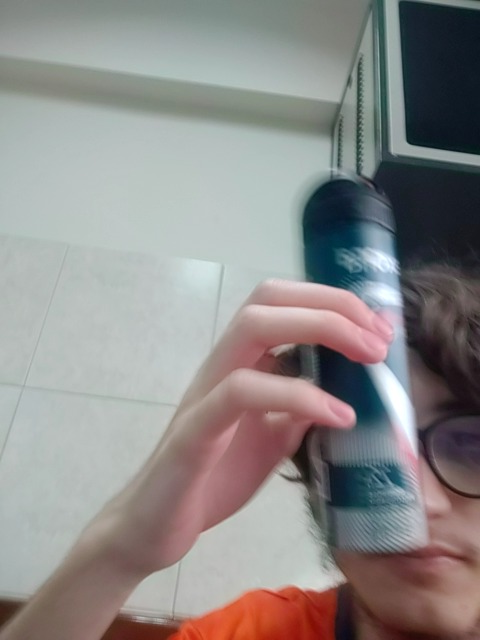

Nenhum objeto detectado


<IPython.core.display.Javascript object>

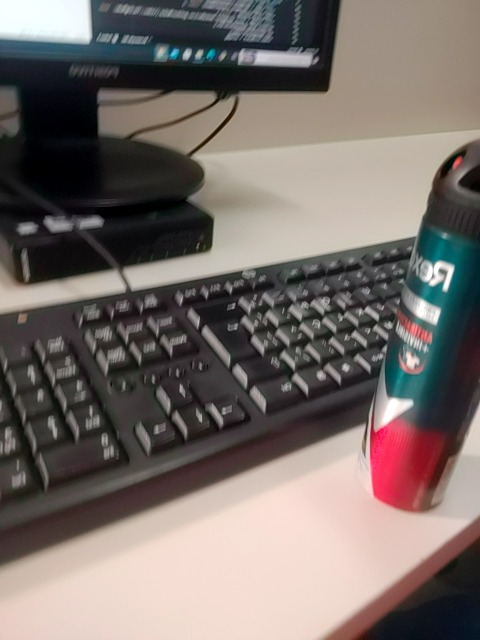

Nenhum objeto detectado


<IPython.core.display.Javascript object>

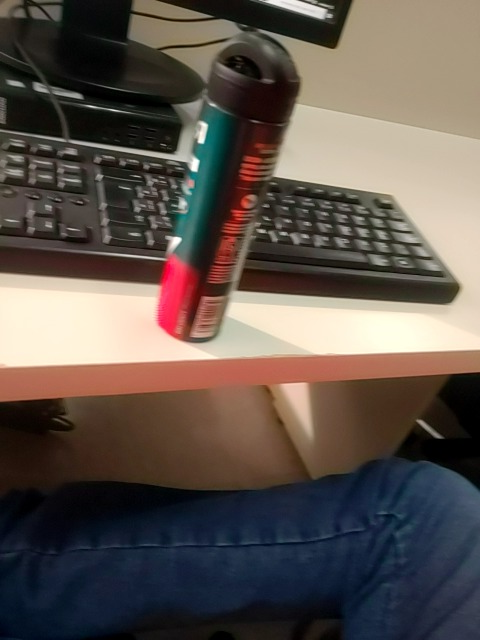

Nenhum objeto detectado


<IPython.core.display.Javascript object>

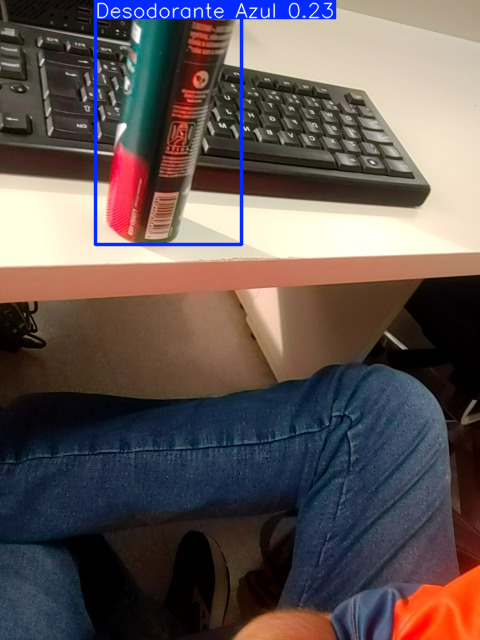

Detectado: Desodorante Azul | Confiança: 23.06%


<IPython.core.display.Javascript object>

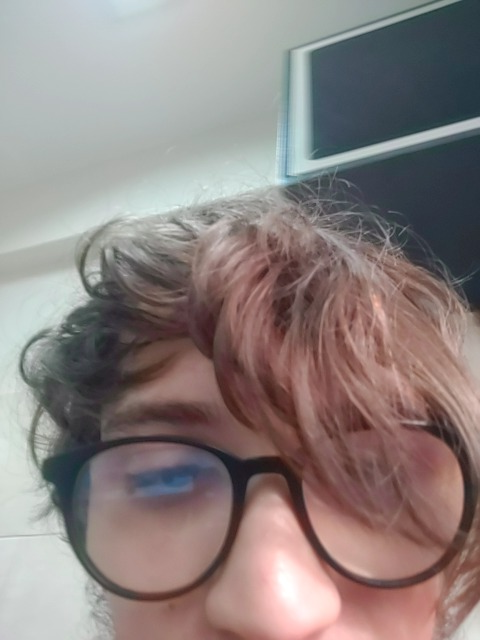

Nenhum objeto detectado


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
import base64, cv2, numpy as np
import time

def capturar_imagem():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video:{facingMode: 'environment'}});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();
            await new Promise((resolve) => setTimeout(resolve, 2000));
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            div.remove();
            return canvas.toDataURL('image/jpeg');
        }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    img = base64.b64decode(data.split(',')[1])
    np_img = np.frombuffer(img, dtype=np.uint8)
    return cv2.imdecode(np_img, cv2.IMREAD_COLOR)

print("Iniciando câmera...")
while True:
    frame = capturar_imagem()
    frame = cv2.flip(frame, 1)

    results = model.predict(frame, imgsz=640, conf=0.1, verbose=False)

    annotated = results[0].plot()
    cv2_imshow(annotated)

    if len(results[0].boxes) == 0:
        print("Nenhum objeto detectado")
    else:
        for r in results[0].boxes:
            classe = model.names[int(r.cls)]
            confianca = float(r.conf)
            print(f"Detectado: {classe} | Confiança: {confianca:.2%}")

#### versao mais rapida

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
import base64, cv2, numpy as np

def video_tempo_real():
    js = Javascript('''
        async function videoLoop() {
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            const output = document.createElement('canvas');
            const ctx = canvas.getContext('2d');

            video.style.display = 'none';
            document.body.appendChild(video);
            document.body.appendChild(output);
            output.style.border = '2px solid green';

            const stream = await navigator.mediaDevices.getUserMedia({
                video: { facingMode: 'environment', width: 640, height: 480 }
            });
            video.srcObject = stream;
            await video.play();

            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            output.width = video.videoWidth;
            output.height = video.videoHeight;

            // Captura um frame como base64
            function getFrame() {
                ctx.drawImage(video, 0, 0);
                return canvas.toDataURL('image/jpeg', 0.6); // 0.6 = qualidade menor = mais rápido
            }

            // Exibe frame anotado recebido do Python
            function showAnnotated(dataUrl) {
                const img = new Image();
                img.onload = () => output.getContext('2d').drawImage(img, 0, 0);
                img.src = dataUrl;
            }

            // Disponibiliza funções globais para o Python chamar
            window._getFrame = getFrame;
            window._showAnnotated = showAnnotated;
            window._stopStream = () => stream.getTracks().forEach(t => t.stop());

            return 'pronto';
        }
    ''')
    display(js)
    eval_js('videoLoop()')

# Inicializa o vídeo
video_tempo_real()
print("Câmera iniciada! Iniciando detecção...")

try:
    while True:
        # Pega frame do JS
        frame_b64 = eval_js('window._getFrame()')
        img_bytes = base64.b64decode(frame_b64.split(',')[1])
        np_img = np.frombuffer(img_bytes, dtype=np.uint8)
        frame = cv2.imdecode(np_img, cv2.IMREAD_COLOR)

        if frame is None:
            continue

        # Roda detecção
        results = model.predict(frame, imgsz=640, conf=0.25, verbose=False)
        annotated = results[0].plot()

        # Envia frame anotado de volta pro JS exibir
        _, buffer = cv2.imencode('.jpg', annotated, [cv2.IMWRITE_JPEG_QUALITY, 80])
        b64_annotated = base64.b64encode(buffer).decode('utf-8')
        eval_js(f'window._showAnnotated("data:image/jpeg;base64,{b64_annotated}")')

        # Mostra detecções no console
        if len(results[0].boxes) > 0:
            for r in results[0].boxes:
                classe = model.names[int(r.cls)]
                conf = float(r.conf)
                print(f"{classe}: {conf:.0%}", end=" | ")
            print()

except KeyboardInterrupt:
    eval_js('window._stopStream()')
    print("Câmera encerrada.")

<IPython.core.display.Javascript object>

Câmera iniciada! Iniciando detecção...
Desodorante Azul: 61% | 
Desodorante Azul: 46% | 
Desodorante Azul: 54% | 
Desodorante Azul: 47% | 
Desodorante Azul: 42% | 
Desodorante Azul: 62% | 
Desodorante Azul: 64% | 
Desodorante Azul: 65% | 
Desodorante Azul: 62% | 
Desodorante Azul: 63% | 
Desodorante Azul: 67% | 
Desodorante Azul: 59% | 
Desodorante Azul: 46% | 
Desodorante Azul: 60% | 
Desodorante Azul: 51% | 
Desodorante Azul: 59% | 
Desodorante Azul: 64% | 
Desodorante Azul: 34% | 
Desodorante Azul: 74% | 
Desodorante Azul: 64% | 
